# 01 — Exploración de datos de celulares

**Pregunta:** ¿qué especificaciones se asocian con las cuatro gamas de precio?

EDA significa análisis exploratorio de datos. Primero comprobamos la calidad;
después exploramos exclusivamente las 1.600 filas de entrenamiento. Las 400 de
test se reservan para el final. Ejecute las celdas en orden con el entorno del proyecto.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "README.profe").exists():
    ROOT = ROOT.parent
if not (ROOT / "README.profe").exists():
    raise RuntimeError("Abra Jupyter desde la raíz del proyecto")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.dataset import load_data, split_data

df = load_data()
X_train, X_test, y_train, y_test = split_data(df)
print("Entrenamiento:", X_train.shape, "Test reservado:", X_test.shape)

Entrenamiento: (1600, 20) Test reservado: (400, 20)


## 1. Auditoría de estructura
Contar nulos o clases no se utiliza para ajustar modelos.

In [2]:
print("Dimensiones:", df.shape)
print("Duplicados:", df.duplicated().sum())
display(pd.DataFrame({"tipo": df.dtypes.astype(str), "nulos": df.isna().sum()}))
display(df.price_range.value_counts().sort_index().rename("filas"))

Dimensiones: (2000, 21)
Duplicados: 0


,tipo,nulos
battery_power,int64,0
blue,int64,0
clock_speed,float64,0
dual_sim,int64,0
fc,int64,0
four_g,int64,0
int_memory,int64,0
m_dep,float64,0
mobile_wt,int64,0
n_cores,int64,0


price_range
0    500
1    500
2    500
3    500
Name: filas, dtype: int64

## 2. Distribuciones del entrenamiento
Los códigos de gama tienen orden, pero no son precios monetarios.

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
count,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.0,1600.00
mean,1236.67,0.49,1.53,0.51,4.32,0.52,32.06,0.50,140.10,4.55,9.87,646.95,1246.49,2125.01,12.28,5.78,10.92,0.76,0.5,0.51
std,438.04,0.50,0.82,0.50,4.34,0.50,18.26,0.29,35.28,2.29,6.07,444.46,429.10,1085.69,4.20,4.39,5.49,0.43,0.5,0.50
min,502.00,0.00,0.50,0.00,0.00,0.00,2.00,0.10,80.00,1.00,0.00,0.00,500.00,256.00,5.00,0.00,2.00,0.00,0.0,0.00
25%,849.50,0.00,0.70,0.00,1.00,0.00,16.00,0.20,109.00,3.00,5.00,282.75,874.00,1209.50,9.00,2.00,6.00,1.00,0.0,0.00
50%,1222.50,0.00,1.50,1.00,3.00,1.00,31.50,0.50,141.00,5.00,10.00,565.50,1247.00,2134.50,12.00,5.00,11.00,1.00,1.0,1.00
75%,1614.00,1.00,2.22,1.00,7.00,1.00,48.00,0.80,170.00,7.00,15.00,954.00,1614.00,3057.50,16.00,9.00,16.00,1.00,1.0,1.00
max,1998.00,1.00,3.00,1.00,19.00,1.00,64.00,1.00,200.00,8.00,20.00,1960.00,1998.00,3998.00,19.00,18.00,20.00,1.00,1.0,1.00


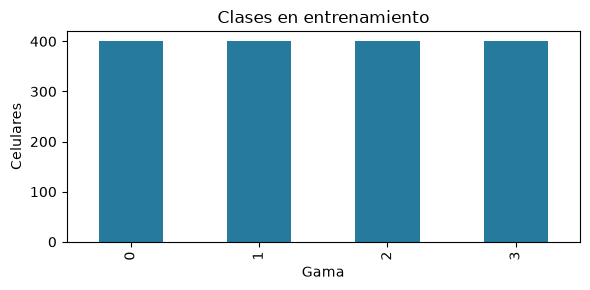

In [3]:
train = X_train.assign(price_range=y_train)
display(X_train.describe().round(2))
fig, ax = plt.subplots(figsize=(6, 3))
y_train.value_counts().sort_index().plot.bar(ax=ax, color="#267a9e")
ax.set(xlabel="Gama", ylabel="Celulares", title="Clases en entrenamiento")
plt.tight_layout()
plt.show()

## 3. Valores que merecen revisión
Un cero en alto de píxeles o ancho físico no describe una pantalla real. Se conserva el dato original y se documenta; no lo sustituimos arbitrariamente.

In [4]:
display((X_train[["px_height", "sc_w"]] == 0).sum().rename("ceros en entrenamiento"))

px_height      1
sc_w         144
Name: ceros en entrenamiento, dtype: int64

## 4. Correlación
Spearman resume asociaciones monotónicas con el orden de las gamas. No demuestra causalidad ni reemplaza la importancia predictiva del modelo.

ram              0.918
battery_power    0.200
px_width         0.160
px_height        0.117
int_memory       0.046
pc               0.043
sc_w             0.030
sc_h             0.028
dual_sim         0.022
wifi             0.017
three_g          0.015
talk_time        0.013
fc               0.013
m_dep            0.012
blue             0.005
four_g           0.004
n_cores          0.004
clock_speed     -0.001
touch_screen    -0.032
mobile_wt       -0.040
Name: Spearman, dtype: float64

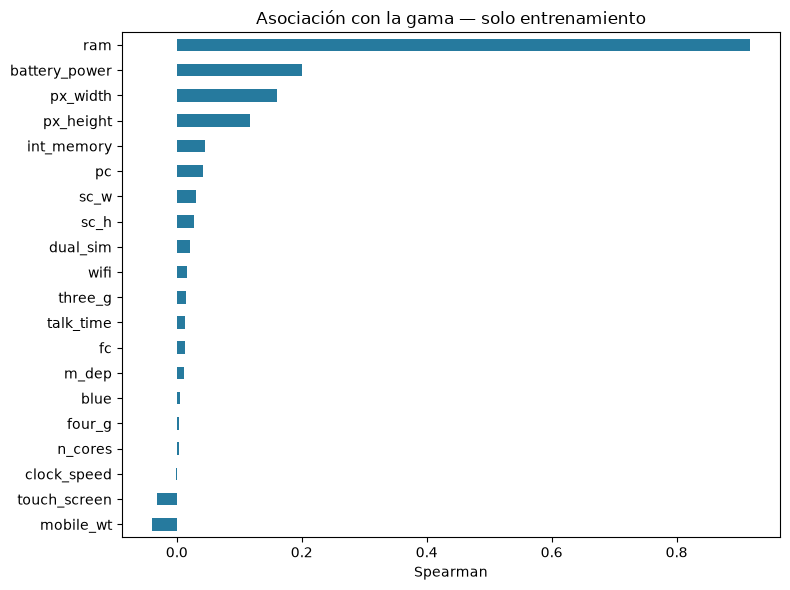

In [5]:
correlation = train.corr(method="spearman")["price_range"].drop("price_range")
display(correlation.sort_values(ascending=False).round(3).rename("Spearman"))
fig, ax = plt.subplots(figsize=(8, 6))
correlation.sort_values().plot.barh(ax=ax, color="#267a9e")
ax.set(title="Asociación con la gama — solo entrenamiento", xlabel="Spearman")
plt.tight_layout()
plt.show()

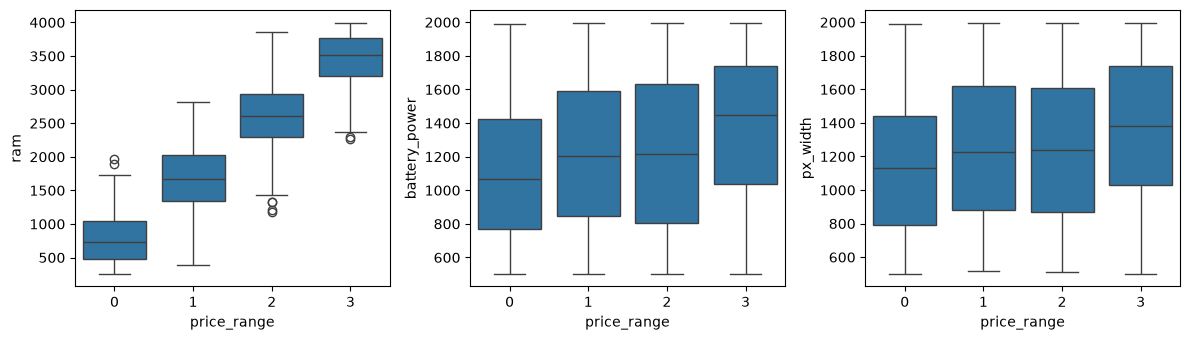

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for column, ax in zip(["ram", "battery_power", "px_width"], axes):
    sns.boxplot(data=train, x="price_range", y=column, ax=ax)
plt.tight_layout()
plt.show()

## 5. Decisiones para modelar

- Conservar inicialmente las 20 variables y las filas originales.
- No aplicar sobremuestreo: las clases están equilibradas.
- Escalar para regresión logística y SVM dentro de cada fold; los árboles no lo requieren.
- Contrastar la hipótesis de RAM leyendo la tabla anterior; una asociación fuerte no significa que defina por sí sola el precio.
- No hay fechas: el monitoreo posterior será una demostración explícitamente simulada hasta contar con lotes reales.

**Para discutir en grupo:** ¿qué variables tienen asociación débil? ¿Puede una variable
con poca correlación ser útil al combinarla con otras? ¿Qué limita trasladar este dataset al mercado actual?
